In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torchvision import transforms
import pytorch_lightning as pl
from torch.utils.data import Dataset, Subset, DataLoader

from hiermoe.constants import *
from hiermoe.extra_functions import set_seed
from hiermoe.data_setup import ImageDataset, HierImageDataset
from hiermoe.hierarchy import Hierarchy

/Users/alexandermichaeltjhin/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/alexandermichaeltjhin/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
set_seed(SEED)
dataset = ImageDataset(
    data_directory = data_directory,
    data_subdirectories = data_subdirectories,
    class_names = ZOOPLANKTON_CLASSES,
    max_class_size = MAX_CLASS_SIZE,
    image_resolution = RESOLUTION,
    image_transforms = None,
    format_file = '.tif',
    seed = SEED
    )

hier_dataset = HierImageDataset(
    base_dataset=dataset,
    adjacency_graph = hier_adjacency_graph,
    levels=3,
    leaves_only=True
)
hier_dataset.print_dataset_details()

[leaves_only] Kept 59810 samples | Removed 1491 non-leaf samples

Total Dataset: Size = 59810 | Levels = 3
all_node_counts: {0: 59810, 1: 37350, 3: 27778, 10: 10000, 11: 10000, 12: 1728, 13: 6050, 4: 6522, 14: 3023, 15: 3499, 6: 3050, 2: 22460, 5: 10000, 7: 4858, 8: 1147, 9: 6455}

nodes_by_level: {0: [0], 1: [1, 2], 2: [3, 4, 6, 5, 7, 8, 9], 3: [10, 11, 12, 13, 14, 15]}


------------------------Level 0------------------------
Level: 0 | Class Name: root                 | Class Label:   0 | Type: Parent | Count:  59810 | Prop: 1.00

------------------------Level 1------------------------
Level: 1 | Class Name: Zoop-yes             | Class Label:   1 | Type: Parent | Count:  37350 | Prop: 0.62
Level: 1 | Class Name: Zoop-No              | Class Label:   2 | Type: Parent | Count:  22460 | Prop: 0.38

------------------------Level 2------------------------
Level: 2 | Class Name: Copepoda             | Class Label:   3 | Type: Parent | Count:  27778 | Prop: 0.46
Level: 2 | Class Name: Cla

In [4]:
from torch.utils.data import Dataset, Subset, DataLoader, SequentialSampler, WeightedRandomSampler, random_split
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.Pad(padding = 5, fill = 0),
    transforms.Resize((RESOLUTION, RESOLUTION)),
    transforms.ToTensor(),
])


hier_dataset.append_image_transforms(
    image_transforms = train_transforms, replace = True
)

TRAIN_PROP = 0.7
VAL_PROP = 0.1
TEST_PROP = 0.2

BATCH_SIZE = 64

train_split, val_split, test_split = hier_dataset.split_train_test_val(
    train_prop = TRAIN_PROP, val_prop = VAL_PROP, test_prop = TEST_PROP
)

# Create dataloaders
train_loader, val_loader, test_loader = hier_dataset.create_dataloaders(
    batch_size = BATCH_SIZE,
    train_indices = train_split,
    val_indices = val_split,
    test_indices = test_split,
    image_transforms = None,
    train_sample_weights = None
)


In [ ]:
class Expert(nn.Module):
    def __init__(self, in_dim, num_children, mode="soft", n_hidden=1):
        super().__init__()
        if n_hidden==0:
            self.layer = nn.Sequential(nn.Linear(in_dim, num_children))
        if n_hidden=1:
            self.layer = nn.Sequential(
                nn.Linear(in_dim, 2*in_dim), 
                nn.ReLU(),
                nn.Linear(2*in_dim, num_children))
        self.mode = mode

    def forward(self, x):
        # x = self.relu(self.fc1(x))
        logits = self.layer(x)
        if self.mode == "soft":
            weights = torch.softmax(logits, dim=-1)
            return weights, logits

        elif self.mode == "hard":
            indices = torch.argmax(logits, dim=-1)
            return indices, logits

        else:
            raise ValueError("mode must be 'soft' or 'hard'")

class HierMoeNet(nn.Module):
    def __init__(self, hierarchy, label_to_id, weights_directory=None,
                 checkpoint_dir=None, seed=123):
        super().__init__()
        self.hierarchy = hierarchy
        self.seed = seed
        self.label_to_id = label_to_id
        backbone = models.efficientnet_b0(weights = weights_directory)
        self.shared = backbone.features
        self.pool = backbone.avgpool
        self.feature_dim = backbone.classifier[1].in_features
        self.local_classifiers = nn.ModuleDict()
        for node_id, node in hierarchy.nodes.items():
            if len(node.children) > 0:
                self.local_classifiers[str(node_id)] = Expert(self.feature_dim,len(node.children))
        self.leaf_index = torch.tensor(hierarchy.get_leaf_index(), dtype=torch.float32)
        self.bce = nn.BCELoss(reduction='none')

        if checkpoint_dir is not None:
            pt_files = list(Path(checkpoint_dir).glob("*.pt"))
            if not pt_files:
                raise FileNotFoundError(f"No .pt file found in '{checkpoint_dir}'")
            checkpoint_path = pt_files[0]
            self.load_state_dict(torch.load(checkpoint_path, map_location="cpu"))
            print(f"Loaded checkpoint: {checkpoint_path}")


    def forward(self, x):
        # --- Backbone ---
        x = self.shared(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)                    # (B, feature_dim)

        # --- Run all local classifiers in one pass ---
        # Store conditional probs for every internal node
        # node_probs[node_id] -> (B, num_children) soft probabilities
        node_probs = {}
        node_logits = {}
        for node_id, classifier in self.local_classifiers.items():
            probs, logits = classifier.forward(x)   # (B, num_children)
            node_probs[node_id] = probs
            node_logits[node_id] = logits

        # --- Compute leaf probabilities via path products ---
        # For each leaf, walk root -> leaf and multiply conditional probs
        # P(leaf) = P(child_k | node_n) * P(node_n | node_n-1) * ... * P(node_1 | root)
        leaf_probs = [-1] * len(self.hierarchy.nodes)
        for node_id, node in self.hierarchy.nodes.items():
            path = self.hierarchy.get_path_to_root(node_id)

            # Start with prob=1 and multiply down the path
            B = x.shape[0]
            prob = torch.ones(B, device=x.device)   # (B,)

            for i in range(len(path) - 1):
                parent = path[i]
                child  = path[i + 1]

                child_idx = self.hierarchy.nodes[parent].children.index(child)

                prob = prob * node_probs[str(parent)][:, child_idx]  # (B,)
            # print(prob)
            leaf_probs[node_id] = prob  # (B,)

        logit_tensor = torch.stack(leaf_probs).transpose(0,1)

        return logit_tensor, node_logits


    def predict(self, x):
        """
        Predict class labels by greedily following argmax decisions from root to leaf,
        recording the expert path taken for each sample.

        Args:
            x: Input tensor of shape (B, C, H, W)

        Returns:
            leaf_ids : LongTensor of shape (B,) — predicted leaf node_id per sample
            paths    : list of lists — paths[i] is [root, ..., leaf] for sample i,
                       reflecting the exact sequence of expert decisions made
        """
        feat = self.shared(x)
        feat = self.pool(feat)
        feat = torch.flatten(feat, 1)           # (B, feature_dim)

        B = feat.shape[0]
        current_nodes = [self.hierarchy.root] * B
        paths = [[self.hierarchy.root] for _ in range(B)]

        while not all(self.hierarchy.is_leaf(n) for n in current_nodes):
            # Group sample indices by their current node
            node_to_indices = {}
            for i, node_id in enumerate(current_nodes):
                if not self.hierarchy.is_leaf(node_id):
                    node_to_indices.setdefault(node_id, []).append(i)

            for node_id, indices in node_to_indices.items():
                group_feat = feat[indices]                                  # (G, feature_dim)
                _, logits = self.local_classifiers[str(node_id)](group_feat)  # (G, num_children)
                child_idx = torch.argmax(logits, dim=-1)                    # (G,)
                children = self.hierarchy.nodes[node_id].children
                for sample_idx, cidx in zip(indices, child_idx.tolist()):
                    next_node = children[cidx]
                    current_nodes[sample_idx] = next_node
                    paths[sample_idx].append(next_node)

        leaf_ids = torch.tensor(current_nodes, dtype=torch.long, device=feat.device)
        return leaf_ids, paths


    def loss_fn(self, logits, targets):
        leaf_index = self.leaf_index.to(logits.device)
        logits = logits.clamp(1e-7, 1 - 1e-7)
        loss = self.bce(logits, targets) * leaf_index
        loss = loss.sum(dim=1) / self.leaf_index.sum()
        return loss.mean()



if torch.backends.mps.is_available():
    device = torch.device('mps')
    print(f'Using device: MPS (Apple Silicon GPU)')
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'Using device: CUDA GPU')
else:
    device = torch.device('cpu')
    print(f'Using device: CPU')

model = HierMoeNet(hier_dataset.hierarchy, hier_dataset.label_to_ids)

Using device: MPS (Apple Silicon GPU)


In [ ]:
import os
import json
import numpy as np
from sklearn.metrics import f1_score, precision_recall_fscore_support

class Trainer:
    def __init__(self, learning_rate, max_epochs, gradient_clip_val=1, device="cpu",
                 print_every: int=5, model_dir=None):
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.gradient_clip_val = gradient_clip_val
        self.device = device
        self.model_dir = model_dir
        self.train_loss = []  
        self.valid_loss = []  
        self.train_acc = []
        self.valid_acc = []
        self.train_f1 = []
        self.valid_f1 = []
        self.print_every = print_every

    @staticmethod
    def clip_gradients(model, max_norm):
        if max_norm:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)

    @staticmethod
    def _get_level_predictions(model, pred_paths, true_ids):
        """
        Aligns predictions and true labels at each hierarchy depth.
        Returns {depth: (preds_array, trues_array)} using the same
        logic as evaluate(), for saving and downstream visualisation.
        """
        true_list = true_ids.tolist()
        max_depth = max(node.depth for node in model.hierarchy.nodes.values())
        level_arrays = {}
        for depth in range(1, max_depth + 1):
            preds_at_depth, trues_at_depth = [], []
            for i, true_id in enumerate(true_list):
                if model.hierarchy.nodes[true_id].depth < depth:
                    continue
                true_path = model.hierarchy.get_path_to_root(true_id)
                pred_path = pred_paths[i]
                trues_at_depth.append(true_path[depth])
                preds_at_depth.append(pred_path[depth] if depth < len(pred_path) else pred_path[-1])
            level_arrays[depth] = (np.array(preds_at_depth), np.array(trues_at_depth))
        return level_arrays

    @staticmethod
    def compute_metrics(leaf_probs, label_node, leaf_index):
        """
        Converts soft predictions and targets to hard class predictions
        over leaf nodes only, then computes accuracy and macro F1.

        Args:
            leaf_probs  : (B, N) predicted probabilities
            label_node  : (B, N) soft ground truth labels
            leaf_index  : (N,)   binary mask — 1 for leaf nodes

        Returns:
            accuracy (float), f1 (float)
        """
        leaf_mask = leaf_index.bool()

        leaf_probs_only  = leaf_probs[:, leaf_mask]
        label_node_only  = label_node[:, leaf_mask]

        pred_classes   = leaf_probs_only.argmax(dim=1).cpu()
        target_classes = label_node_only.argmax(dim=1).cpu()

        accuracy = (pred_classes == target_classes).float().mean().item()
        f1 = f1_score(target_classes.numpy(), pred_classes.numpy(), average="macro", zero_division=0)

        return accuracy, f1


    def fit(self, model, train_loader, valid_loader, optimizer=None, patience=15, delta=0.0005):
        """
        Train the model with early stopping on validation accuracy.

        Args:
            model        : HierMoeNet
            train_loader : DataLoader for training set
            valid_loader : DataLoader for validation set
            optimizer    : Optional pre-built optimizer; Adam is used if None
            patience     : Early stopping patience in epochs (default: 15)
            delta        : Minimum improvement in valid accuracy to count as a new best (default: 0.0005)

        Saves best_model.pt and training_info.json to self.model_dir if set. If the directory
        already exists a numeric suffix is appended (_1, _2, …) to avoid overwriting.
        """
        print(f"Training at device: {self.device}")
        model.to(self.device)
        if optimizer is None:
            optimizer = torch.optim.Adam(model.parameters(), lr=self.learning_rate)

        # --- Output directory with collision safety ---
        actual_dir = None
        if self.model_dir is not None:
            actual_dir = self.model_dir
            suffix = 1
            while os.path.exists(actual_dir):
                actual_dir = f"{self.model_dir}_{suffix}"
                suffix += 1
            os.makedirs(actual_dir)
            if actual_dir != self.model_dir:
                print(f"Directory '{self.model_dir}' already exists — saving to '{actual_dir}' instead.")
                self.model_dir = actual_dir
            best_model_path = os.path.join(actual_dir, "best_model.pt")

        best_val_acc      = -float("inf")
        best_epoch        = -1
        epochs_no_improve = 0

        print("beginning training")
        leaf_mask = model.leaf_index.bool()
        for epoch in range(self.max_epochs):
            model.train()
            train_loss = 0
            train_preds, train_targets = [], []
            
            for i, batch in enumerate(train_loader):
                optimizer.zero_grad()
                image, label_node, path, targets, masks = batch.values()
                image, label_node = image.to(self.device), label_node.to(self.device)
                leaf_tensor, node_logits = model(image)
                
                loss = model.loss_fn(leaf_tensor, label_node)
                loss.backward()
                self.clip_gradients(model, self.gradient_clip_val)
                optimizer.step()
                train_loss += loss.detach().cpu().item()

                train_preds.append(leaf_tensor[:, leaf_mask].argmax(dim=1).detach().cpu())
                train_targets.append(label_node[:, leaf_mask].argmax(dim=1).detach().cpu())

            avg_train_loss = train_loss / len(train_loader)
            train_preds   = torch.cat(train_preds).numpy()
            train_targets = torch.cat(train_targets).numpy()
            train_acc = (train_preds == train_targets).mean()
            train_f1  = f1_score(train_targets, train_preds, average="macro", zero_division=0)

            self.train_loss.append(float(avg_train_loss))
            self.train_acc.append(float(train_acc))
            self.train_f1.append(float(train_f1))

            # --- Validation ---
            model.eval()
            valid_loss = 0
            valid_preds, valid_targets = [], []

            with torch.no_grad():
                for batch in valid_loader:
                    image = batch["image"].to(self.device)
                    label_node = batch["label_node"].to(self.device)

                    leaf_tensor, node_logits = model(image)
                    loss = model.loss_fn(leaf_tensor, label_node)
                    valid_loss += loss.detach().cpu().item()

                    leaf_mask = model.leaf_index.bool()
                    valid_preds.append(leaf_tensor[:, leaf_mask].argmax(dim=1).cpu())
                    valid_targets.append(label_node[:, leaf_mask].argmax(dim=1).cpu())

            avg_valid_loss = valid_loss / len(valid_loader)
            valid_preds   = torch.cat(valid_preds).numpy()
            valid_targets = torch.cat(valid_targets).numpy()
            valid_acc = (valid_preds == valid_targets).mean()
            valid_f1  = f1_score(valid_targets, valid_preds, average="macro", zero_division=0)

            self.valid_loss.append(float(avg_valid_loss))
            self.valid_acc.append(float(valid_acc))
            self.valid_f1.append(float(valid_f1))

            # --- Best model / early stopping ---
            improved = valid_acc > best_val_acc + delta
            if improved:
                best_val_acc = valid_acc
                best_epoch   = epoch + 1
                epochs_no_improve = 0
                if actual_dir is not None:
                    torch.save(model.state_dict(), best_model_path)
                    saved_flag = f" | Saved best model (val_acc={best_val_acc:.4f})"
                else:
                    saved_flag = " *"
            else:
                epochs_no_improve += 1
                saved_flag = ""

            # --- Logging ---
            if (epoch % self.print_every == 0) or (epoch == self.max_epochs - 1) or improved:
                print(
                    f"Epoch [{epoch+1}/{self.max_epochs}] "
                    f"| Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f} "
                    f"| Valid Loss: {avg_valid_loss:.4f} | Valid Acc: {valid_acc:.4f} | Valid F1: {valid_f1:.4f}"
                    f"{saved_flag}"
                )

            if epochs_no_improve >= patience:
                print(f"\nEarly stopping at epoch {epoch+1} — no improvement for {patience} epochs.")
                break

        # --- Save training metadata ---
        if actual_dir is not None:
            training_info = {
                "hyperparameters": {
                    "learning_rate"    : self.learning_rate,
                    "max_epochs"       : self.max_epochs,
                    "gradient_clip_val": self.gradient_clip_val,
                    "patience"         : patience,
                    "delta"            : delta,
                },
                "results": {
                    "best_epoch"        : best_epoch,
                    "best_val_acc"      : float(best_val_acc),
                    "total_epochs_run"  : len(self.train_loss),
                    "early_stopped"     : epochs_no_improve >= patience,
                },
                "training_metrics": {
                    "train_loss": self.train_loss,
                    "train_acc" : self.train_acc,
                    "train_f1"  : self.train_f1,
                    "valid_loss": self.valid_loss,
                    "valid_acc" : self.valid_acc,
                    "valid_f1"  : self.valid_f1,
                },
            }
            info_path = os.path.join(actual_dir, "training_info.json")
            with open(info_path, "w") as f:
                json.dump(training_info, f, indent=2)
            print(f"\nSaved to '{actual_dir}/'")
            print(f"  best_model.pt   — best checkpoint (epoch {best_epoch}, val_acc={best_val_acc:.4f})")
            print(f"  training_info.json — hyperparameters and per-epoch metrics")

    def predict(self, model, pred_loader, save=False):
        """
        Run model.predict() over a loader, call evaluate() and count_mismatches(), and return results.

        Args:
            model       : HierMoeNet
            pred_loader : DataLoader yielding batches with "image" and "label_node" keys
            save        : If True, write predictions.npz and eval_results.json to self.model_dir.
                          predictions.npz includes per-level arrays (level_{d}_preds / trues)
                          needed by Visualize.plot_pred().

        Returns:
            dict with keys: predictions, targets, pred_paths, label_node, level_results, mismatch_results
        """
        model.to(self.device)
        model.eval()

        all_pred_ids    = []
        all_true_ids    = []
        all_label_nodes = []
        all_pred_paths  = []

        with torch.no_grad():
            for batch in pred_loader:
                image      = batch["image"].to(self.device)
                label_node = batch["label_node"]

                pred_ids, pred_paths = model.predict(image)
                pred_ids = pred_ids.cpu()
                true_ids = label_node.argmax(dim=1).cpu()

                all_pred_ids.append(pred_ids)
                all_true_ids.append(true_ids)
                all_label_nodes.append(label_node.cpu())
                all_pred_paths.extend(pred_paths)

        all_pred_ids = torch.cat(all_pred_ids)
        all_true_ids = torch.cat(all_true_ids)

        level_results    = self.evaluate(model, all_pred_ids, all_true_ids, all_pred_paths)
        mismatch_results = self.count_mismatches(model, all_pred_paths)

        if save and self.model_dir is not None:
            # Per-level aligned arrays for confusion matrices in Visualize
            level_arrays = Trainer._get_level_predictions(model, all_pred_paths, all_true_ids)
            save_dict = {
                "predictions": all_pred_ids.numpy(),
                "targets"    : all_true_ids.numpy(),
            }
            for depth, (preds_arr, trues_arr) in level_arrays.items():
                save_dict[f"level_{depth}_preds"] = preds_arr
                save_dict[f"level_{depth}_trues"] = trues_arr
            np.savez(os.path.join(self.model_dir, "predictions.npz"), **save_dict)

            eval_results = {"level_results": level_results, "mismatch_results": mismatch_results}
            with open(os.path.join(self.model_dir, "eval_results.json"), "w") as f:
                json.dump(eval_results, f, indent=2)
            print(f"\nSaved to '{self.model_dir}/'")
            print(f"  predictions.npz  — leaf predictions + per-level aligned arrays")
            print(f"  eval_results.json — level and mismatch results")

        return {
            "predictions"     : all_pred_ids.numpy(),
            "targets"         : all_true_ids.numpy(),
            "pred_paths"      : all_pred_paths,
            "label_node"      : torch.cat(all_label_nodes, dim=0),
            "level_results"   : level_results,
            "mismatch_results": mismatch_results,
        }

    def evaluate(self, model, pred_ids, true_ids, pred_paths):
        """
        Compute per-level and per-class metrics using the expert paths from model.predict().

        At depth d, samples whose true leaf is shallower than d are excluded.
        The predicted node at depth d is taken directly from pred_paths[i][d];
        if the path is shorter than d, the last node in the path is used.

        Overall macro metrics are computed over the true classes only (labels present in
        y_true), so that predictions landing at the wrong depth do not introduce phantom
        zero-F1 classes that deflate the macro average.

        Args:
            model      : HierMoeNet
            pred_ids   : LongTensor (N,) — predicted leaf node_ids
            true_ids   : LongTensor (N,) — true leaf node_ids
            pred_paths : list of lists — expert paths from model.predict(), one per sample

        Returns:
            dict mapping depth (int) -> {
                "overall"  : {accuracy, f1, precision, recall, n_samples},
                "per_class": {class_name -> {node_id, accuracy, f1, precision, recall, n_samples}}
            }
        """
        true_list = true_ids.tolist()

        max_depth = max(node.depth for node in model.hierarchy.nodes.values())

        results = {}
        print("Hierarchical Evaluation:")
        for depth in range(1, max_depth + 1):
            preds_at_depth = []
            trues_at_depth = []

            for i, true_id in enumerate(true_list):
                if model.hierarchy.nodes[true_id].depth < depth:
                    continue

                true_path = model.hierarchy.get_path_to_root(true_id)
                pred_path = pred_paths[i]

                true_node = true_path[depth]
                pred_node = pred_path[depth] if depth < len(pred_path) else pred_path[-1]

                trues_at_depth.append(true_node)
                preds_at_depth.append(pred_node)

            if not trues_at_depth:
                continue

            # unique_classes is derived from true labels only — this ensures macro
            # averaging is restricted to classes that actually exist at this depth,
            # preventing predictions that land at the wrong depth from introducing
            # phantom zero-F1 classes that deflate the overall macro score.
            unique_classes = sorted(set(trues_at_depth))

            # --- Overall macro metrics (restricted to true classes) ---
            acc = sum(p == t for p, t in zip(preds_at_depth, trues_at_depth)) / len(trues_at_depth)
            prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
                trues_at_depth, preds_at_depth, labels=unique_classes, average="macro", zero_division=0
            )

            print(f"  Level {depth}: Acc={acc:.4f} | F1={f1_macro:.4f} | Prec={prec_macro:.4f} | Rec={rec_macro:.4f} | n={len(trues_at_depth)}")

            # --- Per-class metrics ---
            precs, recs, f1s, supports = precision_recall_fscore_support(
                trues_at_depth, preds_at_depth, labels=unique_classes, average=None, zero_division=0
            )

            per_class = {}
            for i, cls_id in enumerate(unique_classes):
                cls_name  = model.hierarchy.nodes[cls_id].name
                n_cls     = int(supports[i])
                correct   = sum(p == t for p, t in zip(preds_at_depth, trues_at_depth) if t == cls_id)
                cls_acc   = correct / n_cls if n_cls > 0 else 0.0
                per_class[cls_name] = {
                    "node_id"  : cls_id,
                    "accuracy" : round(cls_acc, 4),
                    "f1"       : round(float(f1s[i]), 4),
                    "precision": round(float(precs[i]), 4),
                    "recall"   : round(float(recs[i]), 4),
                    "n_samples": n_cls,
                }
                print(f"    {cls_name:<22} Acc={cls_acc:.4f} | F1={f1s[i]:.4f} | Prec={precs[i]:.4f} | Rec={recs[i]:.4f} | n={n_cls}")

            results[depth] = {
                "overall": {
                    "accuracy" : round(acc, 4),
                    "f1"       : round(float(f1_macro), 4),
                    "precision": round(float(prec_macro), 4),
                    "recall"   : round(float(rec_macro), 4),
                    "n_samples": len(trues_at_depth),
                },
                "per_class": per_class,
            }

        return results

    def count_mismatches(self, model, pred_paths):
        """
        Checks structural consistency of predictions using the expert paths from model.predict().

        Every step in each predicted path must be a valid parent->child edge in the hierarchy.

        Args:
            model      : HierMoeNet
            pred_paths : list of lists — expert paths from model.predict(), one per sample

        Returns:
            dict with structural_errors (int), error_pct (float), and passed (bool)
        """
        structural_errors = 0

        for pred_path in pred_paths:
            for i in range(1, len(pred_path)):
                if pred_path[i] not in model.hierarchy.nodes[pred_path[i - 1]].children:
                    structural_errors += 1

        n = len(pred_paths)
        error_pct = round(100 * structural_errors / n, 2) if n > 0 else 0.0

        print("\nStructural Consistency:")
        if structural_errors == 0:
            print(f"  PASSED — all {n} predictions follow a valid path in the hierarchy")
        else:
            print(f"  FAILED — {structural_errors} / {n} predictions ({error_pct:.2f}%) contain an invalid parent->child step")

        return {"structural_errors": structural_errors, "error_pct": error_pct, "passed": structural_errors == 0}

In [15]:
import time
from datetime import date

# train_acc = 0.713
# valid_acc = 0.729
# 7 epochs took 16 minutes

today = date.today()
HYPERPARAMETERS = {
    # 'optimizer': 'Adam', 
    'lr': 3e-4, 
    'epochs': 40, 
    'scheduler':{'type': 'CosineAnnealingLR', 'T_max': 50},
    'early_stopping': {'patience': 15, 'delta': 0.0005},
}
start = time.time()
trainer = Trainer(learning_rate=HYPERPARAMETERS['lr'], max_epochs=HYPERPARAMETERS['epochs'], device=device,
                  print_every=1, model_dir=f"efficient_net_{today}")
trainer.fit(model, train_loader, val_loader)
print(f"Total time taken {round((time.time() - start) / 60, 2)} minutes")

Training at device: mps
Directory 'efficient_net_2026-03-10' already exists — saving to 'efficient_net_2026-03-10_1' instead.
beginning training
Epoch [1/40] | Train Loss: 0.0677 | Train Acc: 0.8296 | Train F1: 0.8259 | Valid Loss: 0.0667 | Valid Acc: 0.8293 | Valid F1: 0.8104 | Saved best model (val_acc=0.8293)
Epoch [2/40] | Train Loss: 0.0670 | Train Acc: 0.8315 | Train F1: 0.8285 | Valid Loss: 0.0698 | Valid Acc: 0.8263 | Valid F1: 0.8112
Epoch [3/40] | Train Loss: 0.0662 | Train Acc: 0.8341 | Train F1: 0.8308 | Valid Loss: 0.0697 | Valid Acc: 0.8258 | Valid F1: 0.8197
Epoch [4/40] | Train Loss: 0.0660 | Train Acc: 0.8348 | Train F1: 0.8323 | Valid Loss: 0.0701 | Valid Acc: 0.8229 | Valid F1: 0.8181
Epoch [5/40] | Train Loss: 0.0651 | Train Acc: 0.8373 | Train F1: 0.8345 | Valid Loss: 0.0664 | Valid Acc: 0.8248 | Valid F1: 0.8176
Epoch [6/40] | Train Loss: 0.0647 | Train Acc: 0.8409 | Train F1: 0.8378 | Valid Loss: 0.0642 | Valid Acc: 0.8351 | Valid F1: 0.8290 | Saved best model (v

In [23]:
# .77 acc, 0.72 f1
# Predict | Accuracy: 0.8200 | F1: 0.8120
model = HierMoeNet(hier_dataset.hierarchy, hier_dataset.label_to_ids, checkpoint_dir=trainer.model_dir)
trainer = Trainer(learning_rate=HYPERPARAMETERS['lr'], max_epochs=HYPERPARAMETERS['epochs'], device=device,
                  print_every=1, model_dir=f"efficient_net_{today}")
result = trainer.predict(model, test_loader, save=True)

Loaded checkpoint: efficient_net_2026-03-10_1/best_model.pt
Hierarchical Evaluation:
  Level 1: Acc=0.9897 | F1=0.9889 | Prec=0.9897 | Rec=0.9882 | n=11962
    Zoop-yes               Acc=0.9940 | F1=0.9919 | Prec=0.9897 | Rec=0.9940 | n=7563
    Zoop-No                Acc=0.9823 | F1=0.9860 | Prec=0.9897 | Rec=0.9823 | n=4399
  Level 2: Acc=0.8976 | F1=0.8496 | Prec=0.8468 | Rec=0.8536 | n=11962
    Copepoda               Acc=0.9821 | F1=0.9788 | Prec=0.9755 | Rec=0.9821 | n=5633
    Cladocera              Acc=0.9443 | F1=0.9414 | Prec=0.9385 | Rec=0.9443 | n=1293
    Debris                 Acc=0.7027 | F1=0.7284 | Prec=0.7562 | Rec=0.7027 | n=1924
    Rotifer                Acc=0.9199 | F1=0.9294 | Prec=0.9391 | Rec=0.9199 | n=637
    Bubbles                Acc=0.9860 | F1=0.9909 | Prec=0.9960 | Rec=0.9860 | n=998
    Exoskeleton            Acc=0.7217 | F1=0.6845 | Prec=0.6510 | Rec=0.7217 | n=230
    Fiber_Squiggly         Acc=0.7185 | F1=0.6940 | Prec=0.6712 | Rec=0.7185 | n=1247
  

# Visualize

Saved → efficient_net_2026-03-10/train_metrics.png


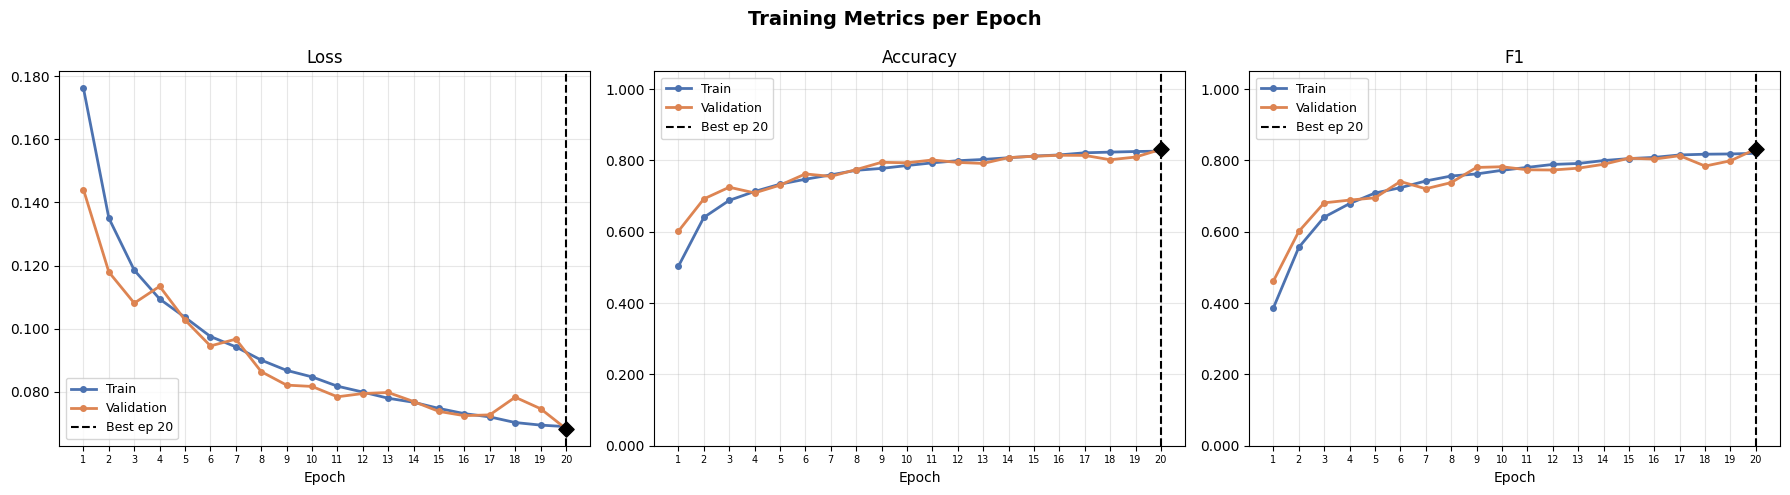

In [25]:
vis = Visualize(trainer.model_dir)
vis.plot_train()

Saved → efficient_net_2026-03-10/confusion_matrix_level1.png


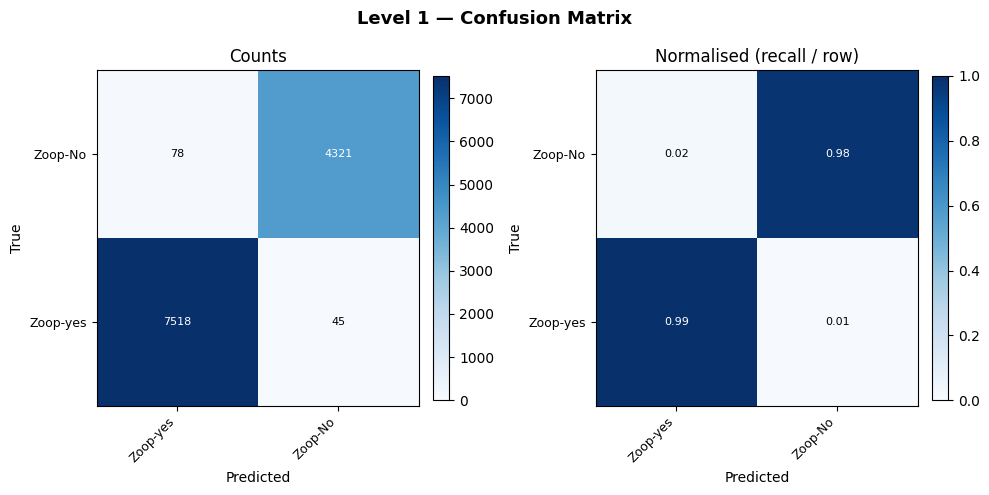

Saved → efficient_net_2026-03-10/class_metrics_level1.png


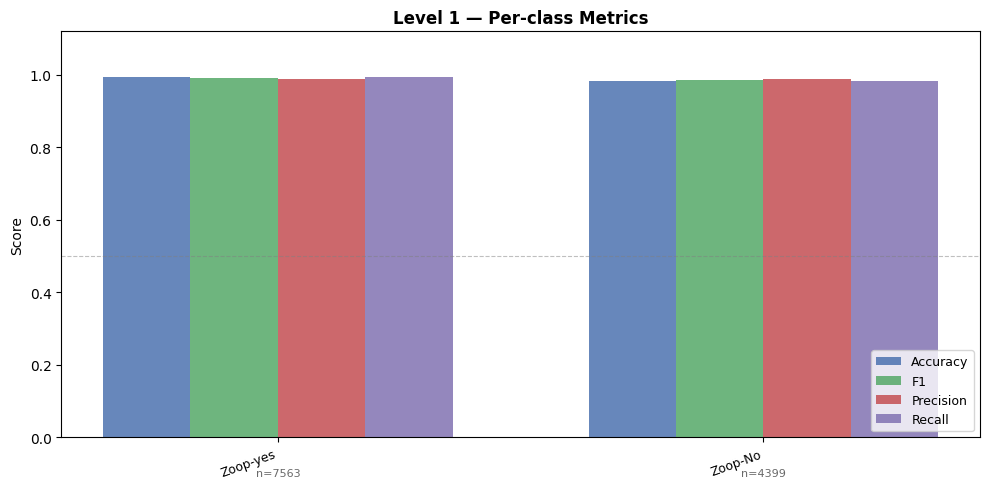

Saved → efficient_net_2026-03-10/confusion_matrix_level2.png


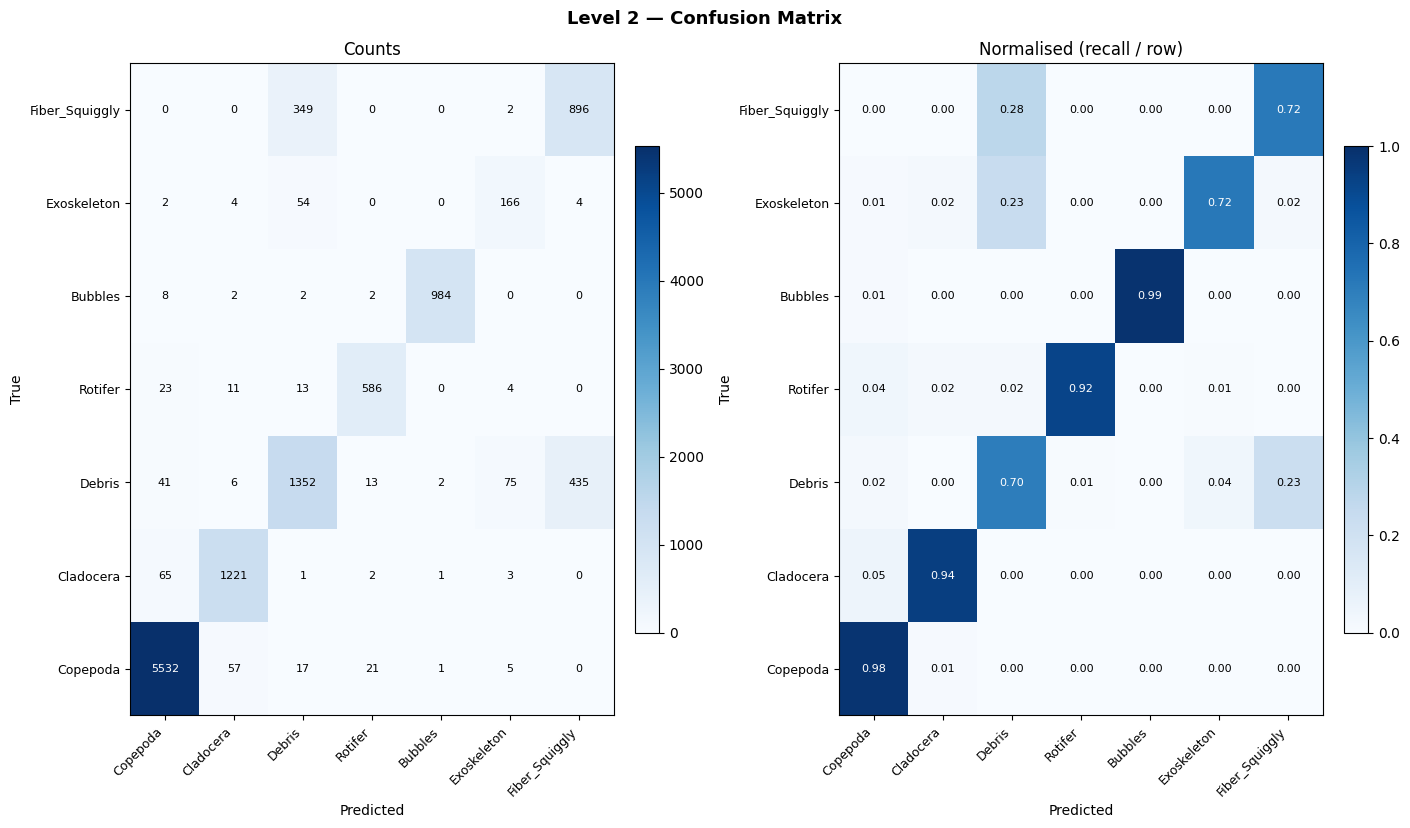

Saved → efficient_net_2026-03-10/class_metrics_level2.png


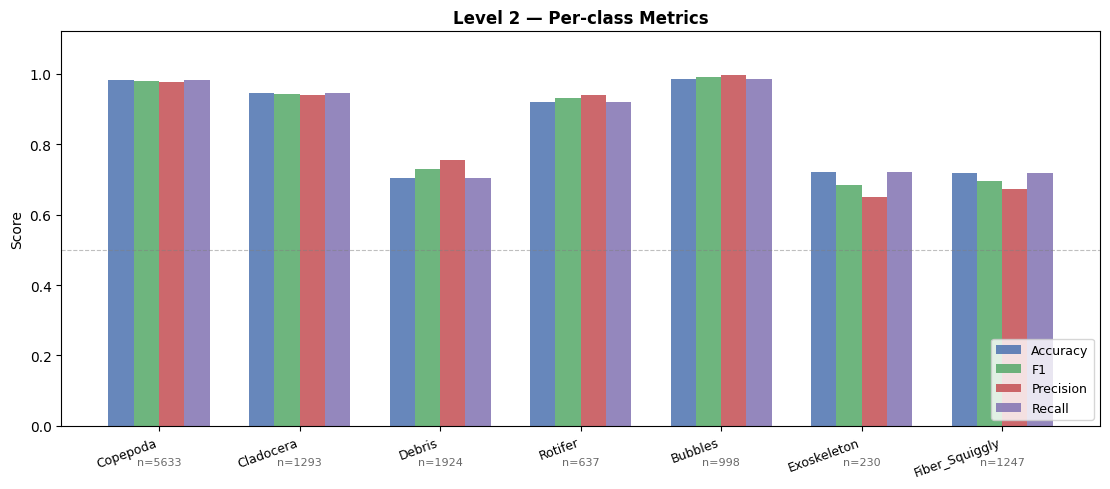

Saved → efficient_net_2026-03-10/confusion_matrix_level3.png


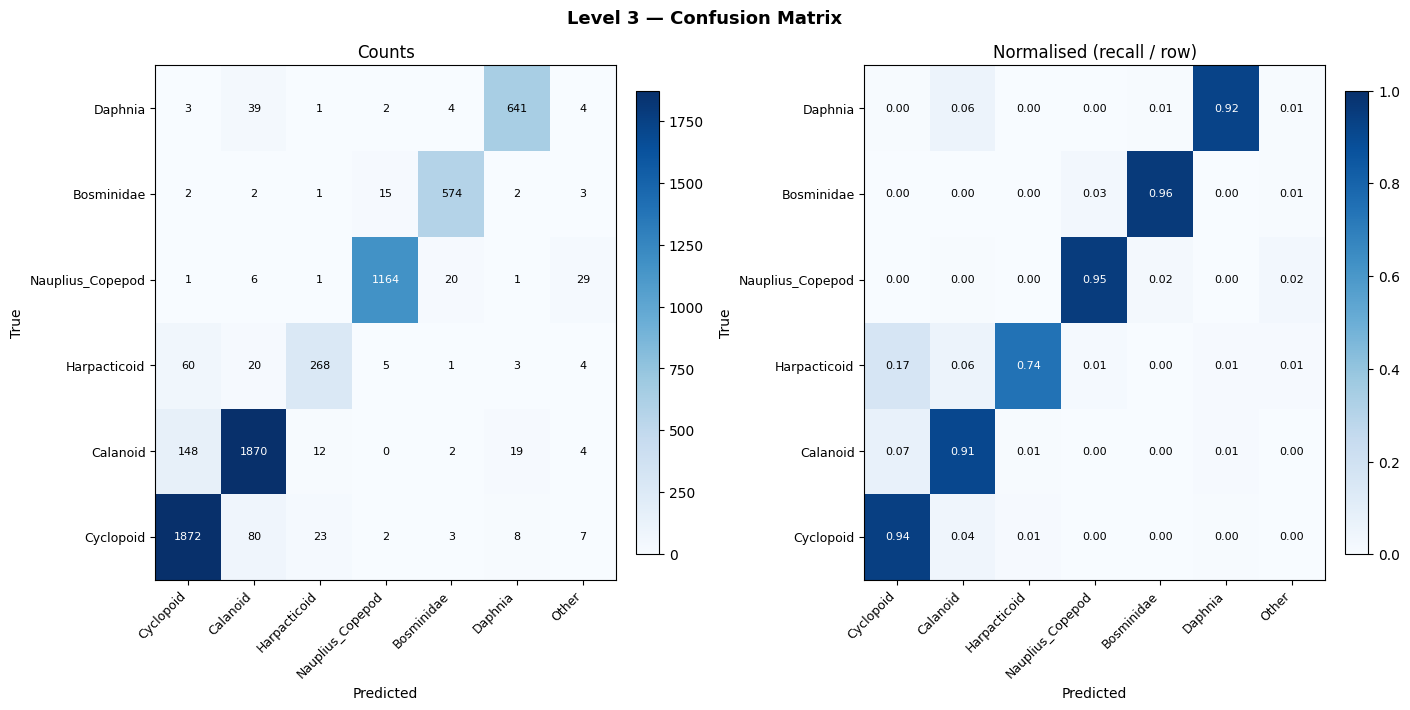

Saved → efficient_net_2026-03-10/class_metrics_level3.png


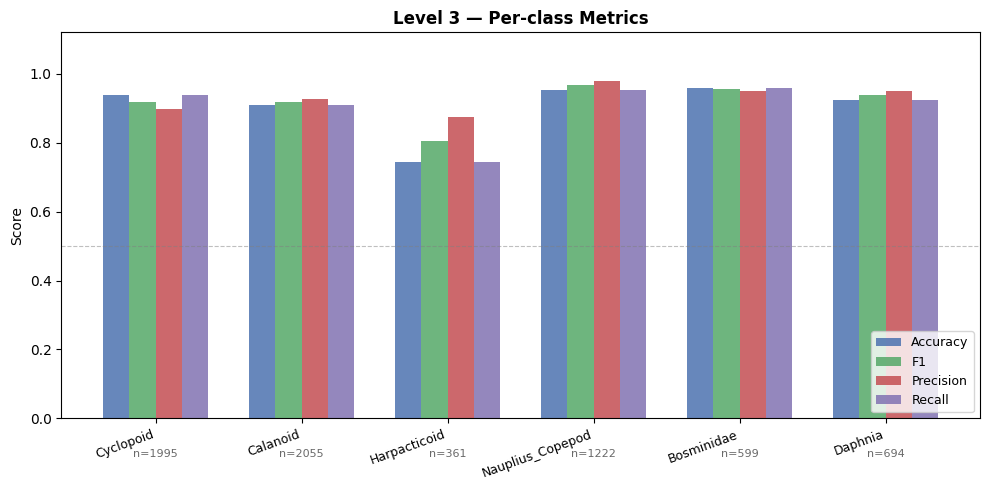

Saved → efficient_net_2026-03-10/level_comparison.png


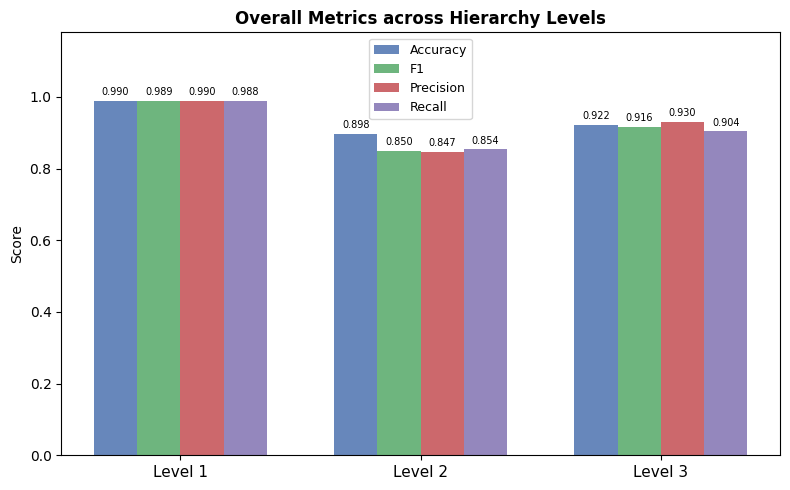

In [26]:
vis.plot_pred()

Saved → efficient_net_2026-03-10/level_comparison.png


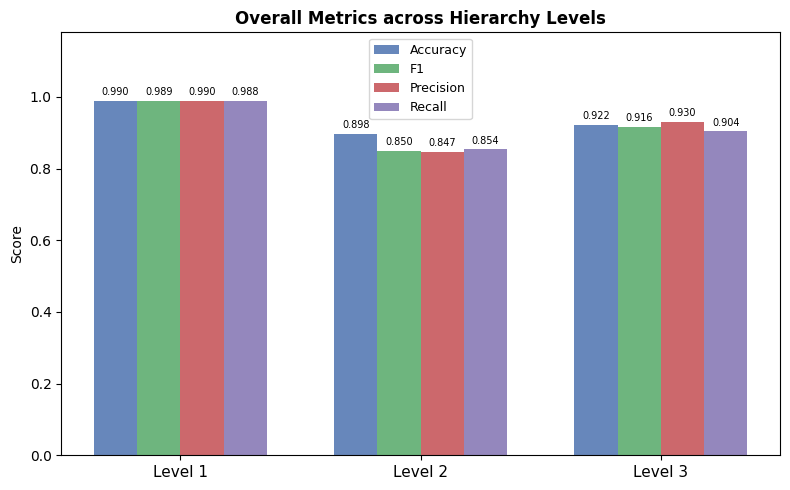

In [27]:
vis.plot_level_comparison()

Saved → efficient_net_2026-03-10/size_vs_accuracy.png


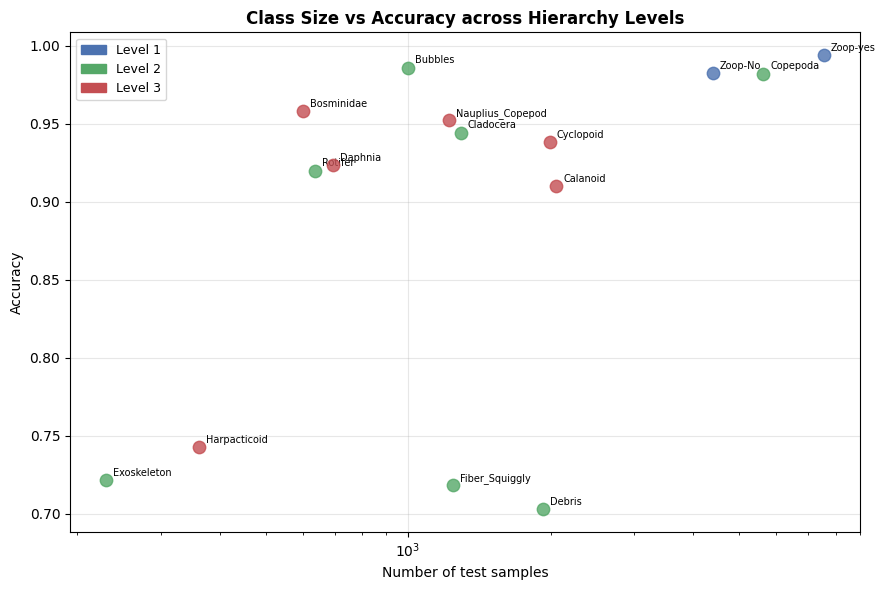

In [28]:
vis.plot_class_size_vs_accuracy()